In [15]:
import sys, os
from typing import Optional
import numpy as np
import pandas as pd
repo_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
if repo_root not in sys.path:
    sys.path.insert(0, repo_root)
print("Added to sys.path:", repo_root)
from fixedincomelib import *
print("Fixed Income Library is loaded.")

Added to sys.path: /Users/sebastienattia/Documents/NYU/Classes/Semester 2/MarketToModel/FRE-GT-9743-Assignment-5
Fixed Income Library is loaded.


# Instructions for HW5:

## PCA implementation

### 1. Write PCA algorithm

Please implement a PCA algorithm without using existing PCA api, which means you're only allowed to use Numpy package.

In [16]:
#source https://www.kaggle.com/code/aurbcd/pca-using-numpy-from-scratch
import numpy as np

def HomeMade_PCA(X, n_components):
    # We start by scaling the data
    X_scaled = (X - X.mean(axis = 0))
    # We compute the covariance matrix
    Cov_X =  (1/(X_scaled.shape[0]-1)) * X_scaled.T @ X_scaled
    eigenvalues, eigenvectors = np.linalg.eig(Cov_X)
    # We order by highest eigenvalues (highest variance)
    idx = np.argsort(eigenvalues)[::-1]
    eigenvalues = eigenvalues[idx]
    eigenvectors = eigenvectors[:, idx]
    # Components
    PCs = eigenvectors[:, :n_components]
    # Projection matrix
    T = X_scaled @ PCs
    return T, PCs, eigenvalues 


### 2. Apply PCA

Please download fixed-floating swap rate data from Bloomberg (Ticker: YCSW0490) covering at least six months, with the sample period ending on 2026-02-26.

Although you should download the data for 2026-02-27, exclude that date from the PCA analysis.

The swap tenors should range from 1Y to 30Y.

The dataset should be organized in the format shown below.

After preparing the dataset, apply Principal Component Analysis (PCA) as discussed in class.

![Chart](data_sample.png)

In [17]:
# I imported the mid from BBG 
df = pd.read_excel("USD_SOFR.xlsx", index_col="Dates")
df

,1Y,2Y,3Y,4Y,5Y,6Y,7Y,8Y,9Y,10Y,12Y,15Y,20Y,25Y,30Y
Dates,,,,,,,,,,,,,,,
2/26/2026,3.4501,3.2581,3.2225,3.2474,3.2937,3.3525,3.4141,3.4745,3.5331,3.5896,3.6951,3.8202,3.9350,3.9613,3.9444
2/25/2026,3.4790,3.3012,3.2699,3.2939,3.3409,3.3985,3.4597,3.5193,3.5774,3.6332,3.7369,3.8616,3.9748,3.9998,3.9819
2/24/2026,3.4685,3.2783,3.2389,3.2585,3.3014,3.3596,3.4217,3.4824,3.5410,3.5978,3.7032,3.8292,3.9440,3.9700,3.9527
2/23/2026,3.4502,3.2516,3.2163,3.2434,3.2919,3.3544,3.4197,3.4833,3.5440,3.6023,3.7119,3.8417,3.9599,3.9883,3.9731
2/20/2026,3.4667,3.2958,3.2759,3.3070,3.3561,3.4194,3.4838,3.5463,3.6055,3.6618,3.7655,3.8896,4.0003,4.0231,4.0034
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9/5/2025,3.6083,3.2765,3.1901,3.1847,3.2172,3.2731,3.3388,3.4083,3.4765,3.5424,3.6648,3.8064,3.9262,3.9489,3.9264
9/4/2025,3.6987,3.3521,3.2538,3.2469,3.2801,3.3414,3.4122,3.4846,3.5550,3.6230,3.7487,3.8918,4.0118,4.0350,4.0125
9/3/2025,3.7318,3.3888,3.2942,3.2920,3.3288,3.3921,3.4647,3.5372,3.6081,3.6761,3.8004,3.9410,4.0575,4.0781,4.0535


In [18]:
T, components, eigenvalues = HomeMade_PCA(df.dropna(), 3)
# Matrix T with our 3 first PCs.
components

array([[-0.06049392, -0.7403177 , -0.50079627],
       [ 0.09983858, -0.45645843, -0.01880691],
       [ 0.18091925, -0.29929541,  0.20436191],
       [ 0.22587503, -0.19530676,  0.28615717],
       [ 0.25245112, -0.12882052,  0.29778525],
       [ 0.26946028, -0.08033721,  0.2591235 ],
       [ 0.27918592, -0.04978455,  0.20185994],
       [ 0.28235969, -0.02971077,  0.13909868],
       [ 0.28434699, -0.01184849,  0.07595986],
       [ 0.28496082,  0.00243762,  0.01597533],
       [ 0.28604961,  0.02816213, -0.08711262],
       [ 0.29040684,  0.06628718, -0.19510867],
       [ 0.29817592,  0.120428  , -0.2916714 ],
       [ 0.30667841,  0.16694918, -0.35081369],
       [ 0.31214153,  0.20429035, -0.38659952]])

In [19]:
tenors = ["1Y","2Y","3Y","4Y","5Y","6Y","7Y","8Y","9Y",
          "10Y","12Y","15Y","20Y","25Y","30Y"]


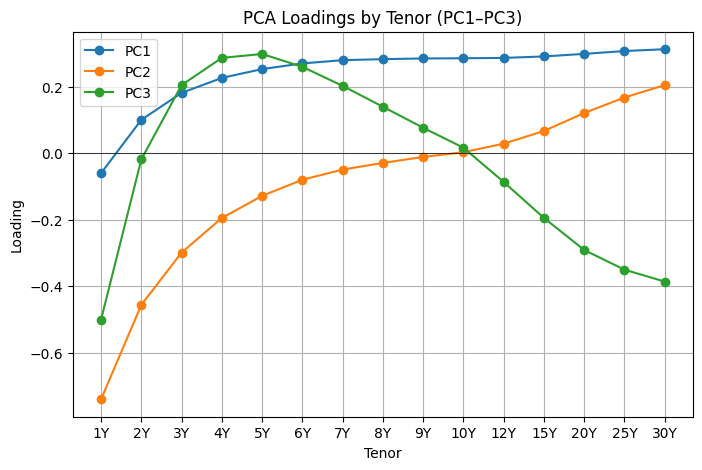

In [20]:
import matplotlib.pyplot as plt
import numpy as np

PCs = np.asarray(components)

plt.figure(figsize=(8,5))

for i in range(PCs.shape[1]):     
    plt.plot(tenors, PCs[:, i], marker='o', label=f"PC{i+1}")

plt.axhline(0, color='black', linewidth=0.5)
plt.xlabel("Tenor")
plt.ylabel("Loading")
plt.title("PCA Loadings by Tenor (PC1–PC3)")
plt.legend()
plt.grid(True)
plt.show()


### 3. Hedging with PCA

With your PCA results, please try to reconstruct the risk profile provided, and present your results.

In [21]:
# read risk_agg.csv
risk_agg = pd.read_csv(os.path.join(repo_root,"risk_agg.csv"))
print("Risk Aggregation Data:")
risk_agg.head()

Risk Aggregation Data:


,Unnamed: 0,1Y,2Y,3Y,4Y,5Y,6Y,7Y,8Y,9Y,10Y,12Y,15Y,20Y,25Y,30Y
0,AGG_RISK,2.982972,-1.857554,0.013279,0.071185,13.975129,-5.458591,-0.025772,-7.003277,0.043624,12.783767,-15.256859,-21.13873,-17.444482,0.0,0.0


In [22]:
tenors = ["1Y", "2Y", "3Y",	"4Y", "5Y", "6Y", "7Y", "8Y", "9Y", "10Y", "12Y", "15Y", "20Y", "25Y" , "30Y"]
r = risk_agg.loc[0, tenors].values
r_with_PCA = components.T @ r 
risk_profile = components @ r_with_PCA
df_riskP = pd.DataFrame({"Risk": risk_profile}, index=tenors)

# How far is the PCA estimate risk profile from the actual risk profile
df_riskP["reconstruction"] = r - df_riskP["Risk"] 
df_riskP

,Risk,reconstruction
1Y,-0.042203,3.025174
2Y,1.497011,-3.354565
3Y,1.959842,-1.946563
4Y,1.643336,-1.572151
5Y,1.017033,12.958096
6Y,0.067165,-5.525756
7Y,-0.883738,0.857967
8Y,-1.747417,-5.25586
9Y,-2.586434,2.630058
10Y,-3.35057,16.134337


The risk reconstruction is not perfect especially on longer tenors. Meaning that approximating the risk with only the first 3 PCs slope, level and curvature might fail to capture the true risk of the position.

Using the provided hedging instruments, solve for the optimal portfolio weights that hedge the aggregated DV01 risk profile. 

Compare the eigenspace approach against direct least squares, and argue mathematically why the former is preferred.

In [23]:
hedging = pd.read_csv(os.path.join(repo_root,"hedging_instruments.csv"))
print("Hedging Instruments Data:")
hedging.head()

Hedging Instruments Data:


,Unnamed: 0,1Y,2Y,3Y,4Y,5Y,6Y,7Y,8Y,9Y,10Y,12Y,15Y,20Y,25Y,30Y
0,1Y1Y,0.990383,-1.905780,-0.040437,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0
1,1Y5Y,0.986415,0.006578,0.000573,0.001714,0.049129,-5.468511,-0.035436,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0
2,5Y5Y,0.002970,0.005982,0.009149,0.012336,4.626952,-0.016352,-0.019360,-0.022309,-0.025584,-8.501197,0.000000,0.000000,0.000000,0.0,0.0
3,10Y10Y,0.003699,0.007465,0.011399,0.015366,0.019642,0.023980,0.028543,0.032885,0.037736,8.499983,-0.093768,-0.198309,-14.335121,0.0,0.0


In [24]:
Hedge = hedging[tenors].T.values.astype(float)

# Exposure to be hedged 

F = components.T @ Hedge
# How a unit of hedging instrument loads on PCs
F


array([[-0.25749837, -1.52956131, -1.2729546 , -1.89117901],
       [ 0.14881398, -0.29900929, -0.62360233, -1.74127696],
       [-0.46840205, -1.9030517 ,  1.23263694,  4.39379406]])

In [25]:
# Weights
f_port = components.T @ r
w, *_ = np.linalg.lstsq(F, -(f_port).astype(float), rcond=None)
# Optimal weights
w


array([-2.83924454, -1.27556113, -4.38486036, -2.14697864])

We obtain all short weights: 
- w1 = -2.84 1Y1Y
- w2 = -1.28 1Y5Y
- w3 = -4.38 5Y5Y
- w4 = -2.14 10Y10Y

In [27]:
# We want to determine weights here.
r_hedged = r + Hedge @ w
df_result = pd.DataFrame({"Original": r,
                          "hedged": r_hedged}, 
                          index=tenors)

df_result["Ori vs. hedged"] = np.abs(df_result["Original"] - df_result["hedged"])
df_result

,Original,hedged,Ori vs. hedged
1Y,2.982972,-1.108165,4.091137
2Y,-1.857554,3.502774,5.360329
3Y,0.013279,0.06277,0.049491
4Y,0.071185,-0.018084,0.089269
5Y,13.975129,-6.418248,20.393377
6Y,-5.458591,1.537043,6.995634
7Y,-0.025772,0.043036,0.068808
8Y,-7.003277,-6.976058,0.027219
9Y,0.043624,0.074789,0.031165
10Y,12.783767,31.811045,19.027279


The hedge is not working perfectly especially on the 5Y, 10Y and 20Y tenors. This is one of the drawback with PCA. However, it works on most of the other tenors.

 The PCA hedge fails to capture the risk on long term tenors ~15/20Y. However, compared to OLS, PCA explains more with fewer parameters (parsimony). Moreover, a linear regression model as various assumptions. If not respected, the results obtained can be considered spurious.